In [ ]:
import xarray as xr
import pandas as pd
import os

print("读取 nc 文件...")
ds2020 = xr.open_dataset('/root/UK2020full.nc')
ds2021 = xr.open_dataset('/root/UK2021full.nc')
ds = xr.concat([ds2020, ds2021], dim='valid_time')
print(f"合并后时间步: {len(ds.valid_time)}")  # 17544

print("转换为 DataFrame...")
df = ds.to_dataframe().reset_index()

KEEP = ['valid_time', 'latitude', 'longitude',
        'u10', 'v10', 'd2m', 't2m', 'sp', 'tcc', 'tp']
df = df[KEEP].reset_index(drop=True)

# 时间格式和 ie_full.csv 一致
df['valid_time'] = pd.to_datetime(df['valid_time']).dt.strftime('%Y-%m-%d %H:%M:%S')

print(f"shape: {df.shape}")
print(df.head(3))

print("\n保存 CSV 中，需要等待15~20分钟...")
df.to_csv('/root/uk_full.csv', index=False)

size = os.path.getsize('/root/uk_full.csv') / 1024**2
print(f"✅ 完成！文件大小: {size:.0f} MB")

In [4]:
import pandas as pd

# 只读前3行对比
uk_check = pd.read_csv('/root/uk_full.csv', nrows=3)
ie_check = pd.read_csv('/root/ie_full.csv', nrows=3)

print("=== UK ===")
print(uk_check)
print(uk_check.dtypes)

print("\n=== IE ===")
print(ie_check)
print(ie_check.dtypes)

print("\n列名一致:", list(uk_check.columns) == list(ie_check.columns))

=== UK ===
            valid_time  latitude  longitude        u10        v10        d2m  \
0  2020-01-01 00:00:00      61.0     -11.00   9.854370  13.138718  280.30322   
1  2020-01-01 00:00:00      61.0     -10.75  10.056519  12.955124  280.37550   
2  2020-01-01 00:00:00      61.0     -10.50  10.008667  12.638718  280.46533   

         t2m          sp  tcc        tp  
0  282.64550  100818.375  1.0  0.000020  
1  282.65332  100843.375  1.0  0.000012  
2  282.65918  100879.375  1.0  0.000015  
valid_time        str
latitude      float64
longitude     float64
u10           float64
v10           float64
d2m           float64
t2m           float64
sp            float64
tcc           float64
tp            float64
dtype: object

=== IE ===
            valid_time  latitude  longitude       u10        v10        d2m  \
0  2020-01-01 00:00:00      56.0     -11.00  2.703003  10.192429  281.21924   
1  2020-01-01 00:00:00      52.5      -9.00 -1.231567   1.090866  277.35596   
2  2020-01-01 00:

In [ ]:
#构建滑动窗口函数

In [6]:
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

WINDOW = 12
FEATURES = ['u10', 'v10', 'd2m', 't2m', 'sp', 'tcc', 'tp']

def build_sliding_window(df, lead, window=WINDOW, features=FEATURES):
    all_X, all_y = [], []
    grid_points = df.groupby(['latitude', 'longitude'])
    total = len(grid_points)
    print(f"共 {total} 个网格点，lead=t+{lead}...")

    for i, ((lat, lon), grp) in enumerate(grid_points):
        if i % 500 == 0:
            print(f"  进度: {i}/{total}")
        grp = grp.sort_values('valid_time').reset_index(drop=True)
        data = grp[features].values
        T = len(data)
        for t in range(window, T - lead + 1):
            all_X.append(data[t-window : t])
            all_y.append(data[t + lead - 1, features.index('tp')])

    X = np.array(all_X, dtype=np.float32)
    y = np.array(all_y, dtype=np.float32)
    print(f"完成！X={X.shape}, y={y.shape}")
    return X, y

print("✅ 函数定义完成")

✅ 函数定义完成


In [ ]:
#step3:读取数据并构建 UK t+6 窗口

In [14]:
import pandas as pd

print("读取 uk_full.csv...")
uk = pd.read_csv('/root/uk_full.csv')
print(f"UK shape: {uk.shape}")

print("\n构建 UK t+6 滑动窗口（需要约10~20分钟）...")
X_uk_6, y_uk_6 = build_sliding_window(uk, lead=6)

np.save('/root/autodl-tmp/X_uk_lead6.npy', X_uk_6)
np.save('/root/autodl-tmp/y_uk_lead6.npy', y_uk_6)
print("✅ UK t+6 保存完成")

读取 uk_full.csv...
UK shape: (49000392, 10)

构建 UK t+6 滑动窗口（需要约10~20分钟）...
共 2793 个网格点，lead=t+6...
  进度: 0/2793
  进度: 500/2793
  进度: 1000/2793
  进度: 1500/2793
  进度: 2000/2793
  进度: 2500/2793
完成！X=(48952911, 12, 7), y=(48952911,)
✅ UK t+6 保存完成


In [ ]:
#构建 UK t+12 窗口

In [16]:
print("构建 UK t+12 滑动窗口（需要约10~20分钟）...")
X_uk_12, y_uk_12 = build_sliding_window(uk, lead=12)

np.save('/root/autodl-tmp/X_uk_lead12.npy', X_uk_12)
np.save('/root/autodl-tmp/y_uk_lead12.npy', y_uk_12)
print("✅ UK t+12 保存完成")

构建 UK t+12 滑动窗口（需要约10~20分钟）...
共 2793 个网格点，lead=t+12...
  进度: 0/2793
  进度: 500/2793
  进度: 1000/2793
  进度: 1500/2793
  进度: 2000/2793
  进度: 2500/2793
完成！X=(48936153, 12, 7), y=(48936153,)
✅ UK t+12 保存完成


In [17]:
# 释放 uk 和 X_uk_6/12 内存
del uk, X_uk_6, y_uk_6, X_uk_12, y_uk_12
import gc
gc.collect()
print("✅ 内存已释放")

✅ 内存已释放


In [18]:
# 读取 Ireland 数据
import pandas as pd
print("读取 ie_full.csv...")
ie = pd.read_csv('/root/ie_full.csv')
print(f"IE shape: {ie.shape}")

# 构建 t+6
print("\n构建 Ireland t+6 滑动窗口...")
X_ie_6, y_ie_6 = build_sliding_window(ie, lead=6)
np.save('/root/autodl-tmp/X_ie_lead6.npy', X_ie_6)
np.save('/root/autodl-tmp/y_ie_lead6.npy', y_ie_6)
print("✅ Ireland t+6 保存完成")

# 构建 t+12
print("\n构建 Ireland t+12 滑动窗口...")
X_ie_12, y_ie_12 = build_sliding_window(ie, lead=12)
np.save('/root/autodl-tmp/X_ie_lead12.npy', X_ie_12)
np.save('/root/autodl-tmp/y_ie_lead12.npy', y_ie_12)
print("✅ Ireland t+12 保存完成")

读取 ie_full.csv...
IE shape: (9210600, 10)

构建 Ireland t+6 滑动窗口...
共 525 个网格点，lead=t+6...
  进度: 0/525
  进度: 500/525
完成！X=(9201675, 12, 7), y=(9201675,)
✅ Ireland t+6 保存完成

构建 Ireland t+12 滑动窗口...
共 525 个网格点，lead=t+12...
  进度: 0/525
  进度: 500/525
完成！X=(9198525, 12, 7), y=(9198525,)
✅ Ireland t+12 保存完成


In [ ]:
第4步 — 划分 train/val/test

In [19]:
import numpy as np
import pandas as pd

WINDOW    = 12
N_GRID_UK = 2793
N_GRID_IE = 525

# 每个网格点的样本数
N_TIMES_6  = 17544 - WINDOW - 6  + 1   # 17527
N_TIMES_12 = 17544 - WINDOW - 12 + 1   # 17521

# 时间序列
times_6  = pd.date_range("2020-01-01 18:00", periods=N_TIMES_6,  freq="h")
times_12 = pd.date_range("2020-01-02 00:00", periods=N_TIMES_12, freq="h")

def make_masks(times):
    train = times < "2021-01-01"
    val   = (times >= "2021-01-01") & (times < "2021-07-01")
    test  = times >= "2021-07-01"
    return train, val, test

train_mask_6,  val_mask_6,  test_mask_6  = make_masks(times_6)
train_mask_12, val_mask_12, test_mask_12 = make_masks(times_12)

print(f"t+6  — Train: {train_mask_6.sum()}, Val: {val_mask_6.sum()}, Test: {test_mask_6.sum()}")
print(f"t+12 — Train: {train_mask_12.sum()}, Val: {val_mask_12.sum()}, Test: {test_mask_12.sum()}")

# 展开为样本级别索引
def make_idx(mask, n_grid):
    return np.where(np.tile(mask, n_grid))[0]

# t+6 索引
uk_train_idx_6  = make_idx(train_mask_6, N_GRID_UK)
uk_val_idx_6    = make_idx(val_mask_6,   N_GRID_UK)
uk_test_idx_6   = make_idx(test_mask_6,  N_GRID_UK)
ie_train_idx_6  = make_idx(train_mask_6, N_GRID_IE)
ie_val_idx_6    = make_idx(val_mask_6,   N_GRID_IE)
ie_test_idx_6   = make_idx(test_mask_6,  N_GRID_IE)

# t+12 索引
uk_train_idx_12 = make_idx(train_mask_12, N_GRID_UK)
uk_val_idx_12   = make_idx(val_mask_12,   N_GRID_UK)
uk_test_idx_12  = make_idx(test_mask_12,  N_GRID_UK)
ie_train_idx_12 = make_idx(train_mask_12, N_GRID_IE)
ie_val_idx_12   = make_idx(val_mask_12,   N_GRID_IE)
ie_test_idx_12  = make_idx(test_mask_12,  N_GRID_IE)

print(f"\nt+6  UK — Train: {len(uk_train_idx_6)}, Val: {len(uk_val_idx_6)}, Test: {len(uk_test_idx_6)}")
print(f"t+6  IE — Train: {len(ie_train_idx_6)}, Val: {len(ie_val_idx_6)}, Test: {len(ie_test_idx_6)}")
print(f"\nt+12 UK — Train: {len(uk_train_idx_12)}, Val: {len(uk_val_idx_12)}, Test: {len(uk_test_idx_12)}")
print(f"t+12 IE — Train: {len(ie_train_idx_12)}, Val: {len(ie_val_idx_12)}, Test: {len(ie_test_idx_12)}")
print("✅ 第4步完成")

t+6  — Train: 8766, Val: 4344, Test: 4417
t+12 — Train: 8760, Val: 4344, Test: 4417

t+6  UK — Train: 24483438, Val: 12132792, Test: 12336681
t+6  IE — Train: 4602150, Val: 2280600, Test: 2318925

t+12 UK — Train: 24466680, Val: 12132792, Test: 12336681
t+12 IE — Train: 4599000, Val: 2280600, Test: 2318925
✅ 第4步完成


In [ ]:
#第5步 — 加载 scaler（直接用 t+1 的）

In [22]:
import joblib

scaler_X    = joblib.load('/root/scaler_X.pkl')
scaler_y    = joblib.load('/root/scaler_y.pkl')
scaler_X_ie = joblib.load('/root/scaler_X_ie.pkl')
scaler_y_ie = joblib.load('/root/scaler_y_ie.pkl')

print("scaler_X mean:", scaler_X.mean_[:3], "...")
print("scaler_y mean:", scaler_y.mean_)
print("✅ 第5步完成")

scaler_X mean: [  2.2944224    1.36668514 280.25203351] ...
scaler_y mean: [0.00013611]
✅ 第5步完成


In [ ]:
第6步 — baseline

In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib

# 基本设置
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", DEVICE)

# 加载scaler（复用t+1的）
scaler_X = joblib.load("/root/scaler_X.pkl")
scaler_y = joblib.load("/root/scaler_y.pkl")

# 加载数据
X_uk = np.load("/root/autodl-tmp/X_uk_lead6.npy", mmap_mode='r')
y_uk = np.load("/root/autodl-tmp/y_uk_lead6.npy", mmap_mode='r')

# 时间索引（t+6 参数）
N_TIMES   = 17527          # 17544 - 12 - 6 + 1
N_GRID_UK = 2793
uk_times = pd.date_range("2020-01-01 18:00", periods=N_TIMES, freq="h")
uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"

train_idx = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
val_idx   = np.where(np.tile(uk_val_mask,   N_GRID_UK))[0]
test_idx  = np.where(np.tile(uk_test_mask,  N_GRID_UK))[0]

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print("数据加载完成")

使用设备: cuda
Train: 24483438, Val: 12132792, Test: 12336681
数据加载完成


In [24]:
#定义 Dataset 和 Deterministic LSTM

from sklearn.metrics import r2_score

class RainfallDataset(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class DeterministicLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

print("创建 Dataset...")
train_dataset = RainfallDataset(X_uk, y_uk, train_idx, scaler_X, scaler_y)
val_dataset   = RainfallDataset(X_uk, y_uk, val_idx,   scaler_X, scaler_y)
train_loader  = DataLoader(train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
val_loader    = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=4)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset:   {len(val_dataset)}")
print("✅ Dataset 和模型定义完成")

创建 Dataset...
Train dataset: 24483438
Val dataset:   12132792
✅ Dataset 和模型定义完成


In [25]:
# 步骤6：训练 Deterministic LSTM (t+6)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
from sklearn.metrics import r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", DEVICE)

scaler_X = joblib.load("/root/scaler_X.pkl")
scaler_y = joblib.load("/root/scaler_y.pkl")

# ← 改1：数据路径
X_uk = np.load("/root/autodl-tmp/X_uk_lead6.npy", mmap_mode='r')
y_uk = np.load("/root/autodl-tmp/y_uk_lead6.npy", mmap_mode='r')

# ← 改2：N_TIMES
N_TIMES = 17527
N_GRID_UK = 2793
# ← 改3：时间起点
uk_times = pd.date_range("2020-01-01 18:00", periods=N_TIMES, freq="h")
uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"
train_idx = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
val_idx   = np.where(np.tile(uk_val_mask,   N_GRID_UK))[0]
test_idx  = np.where(np.tile(uk_test_mask,  N_GRID_UK))[0]

class RainfallDataset(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class DeterministicLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

print("创建Dataset...")
train_dataset = RainfallDataset(X_uk, y_uk, train_idx, scaler_X, scaler_y)
val_dataset   = RainfallDataset(X_uk, y_uk, val_idx,   scaler_X, scaler_y)
train_loader  = DataLoader(train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
val_loader    = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=4)
print("准备完成，开始训练...")

model     = DeterministicLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
EPOCHS    = 10
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = model(X_batch)
            val_loss += criterion(pred, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # ← 改4：模型保存路径
        torch.save(model.state_dict(), "/root/autodl-tmp/best_deterministic_lead6.pth")
        print(f"  ✓ 保存最优模型")

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

使用设备: cuda
创建Dataset...
准备完成，开始训练...
Epoch 1/10 | Train Loss: 0.6871 | Val Loss: 0.6040
  ✓ 保存最优模型
Epoch 2/10 | Train Loss: 0.5689 | Val Loss: 0.6203
Epoch 3/10 | Train Loss: 0.5238 | Val Loss: 0.6206
Epoch 4/10 | Train Loss: 0.4969 | Val Loss: 0.6322
Epoch 5/10 | Train Loss: 0.4777 | Val Loss: 0.6357
Epoch 6/10 | Train Loss: 0.4642 | Val Loss: 0.6380
Epoch 7/10 | Train Loss: 0.4537 | Val Loss: 0.6373
Epoch 8/10 | Train Loss: 0.4450 | Val Loss: 0.6318
Epoch 9/10 | Train Loss: 0.4374 | Val Loss: 0.6417
Epoch 10/10 | Train Loss: 0.4315 | Val Loss: 0.6410
训练完成！最优Val Loss: 0.6040


In [26]:
# 正式训练 Deterministic LSTM (t+6) — 正式版

model = DeterministicLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

EPOCHS = 30
best_val_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = model(X_batch)
            val_loss += criterion(pred, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 唯一改动：保存路径
        torch.save(model.state_dict(), "/root/autodl-tmp/best_deterministic_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.7624 | Val Loss: 0.5812
  ✓ 保存最优模型 (val_loss=0.5812)
Epoch 2/30 | Train Loss: 0.6728 | Val Loss: 0.5911
Epoch 3/30 | Train Loss: 0.6259 | Val Loss: 0.5966
Epoch 4/30 | Train Loss: 0.5932 | Val Loss: 0.6071
Epoch 5/30 | Train Loss: 0.5689 | Val Loss: 0.6061
Epoch 6/30 | Train Loss: 0.5499 | Val Loss: 0.6188
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.5812


In [27]:
#评估 Deterministic LSTM (t+6)

model.load_state_dict(torch.load("/root/autodl-tmp/best_deterministic_lead6.pth"))
model.eval()

test_dataset = RainfallDataset(X_uk, y_uk, test_idx, scaler_X, scaler_y)
test_loader  = DataLoader(test_dataset, batch_size=4096, shuffle=False, num_workers=4)

all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch).cpu().numpy()
        all_preds.append(pred)
        all_true.append(y_batch.numpy())

preds = np.concatenate(all_preds)
trues = np.concatenate(all_true)

preds_orig = scaler_y.inverse_transform(preds.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse = np.sqrt(np.mean((preds_orig - trues_orig)**2))
r2   = r2_score(trues_orig, preds_orig)

print(f"=== Deterministic LSTM Test Results (t+6) ===")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.4f}")

=== Deterministic LSTM Test Results (t+6) ===
RMSE: 0.000334
R²:   0.1515


In [ ]:
#步骤7：Uncertainty-aware baseline（mean+variance）

In [28]:
# 步骤7：训练 Uncertainty LSTM (t+6)

class UncertaintyLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc_mean = nn.Linear(hidden_size, 1)
        self.fc_var  = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        mean = self.fc_mean(h).squeeze(-1)
        var  = torch.nn.functional.softplus(self.fc_var(h)).squeeze(-1) + 1e-6
        return mean, var

def nll_loss(mean, var, target):
    return (torch.log(var) + (target - mean)**2 / var).mean()

model_unc = UncertaintyLSTM().to(DEVICE)
optimizer_unc = torch.optim.Adam(model_unc.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_unc.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_unc.zero_grad()
        mean, var = model_unc(X_batch)
        loss = nll_loss(mean, var, y_batch)
        loss.backward()
        optimizer_unc.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_unc.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            mean, var = model_unc(X_batch)
            val_loss += nll_loss(mean, var, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 唯一改动：保存路径
        torch.save(model_unc.state_dict(), "/root/autodl-tmp/best_uncertainty_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: -0.5003 | Val Loss: 1.9650
  ✓ 保存最优模型 (val_loss=1.9650)
Epoch 2/30 | Train Loss: -0.7996 | Val Loss: 3.2372
Epoch 3/30 | Train Loss: -0.9612 | Val Loss: 16.7617
Epoch 4/30 | Train Loss: -1.0631 | Val Loss: 23.8061
Epoch 5/30 | Train Loss: -1.1571 | Val Loss: 89.6099
Epoch 6/30 | Train Loss: -1.2413 | Val Loss: 130.7679
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 1.9650


In [29]:
# 步骤7：评估 Uncertainty LSTM (t+6)

model_unc.load_state_dict(torch.load("/root/autodl-tmp/best_uncertainty_lead6.pth"))
model_unc.eval()

all_means, all_vars, all_true = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        mean, var = model_unc(X_batch)
        all_means.append(mean.cpu().numpy())
        all_vars.append(var.cpu().numpy())
        all_true.append(y_batch.numpy())

means = np.concatenate(all_means)
vars_ = np.concatenate(all_vars)
trues = np.concatenate(all_true)

means_orig = scaler_y.inverse_transform(means.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse = np.sqrt(np.mean((means_orig - trues_orig)**2))
r2   = r2_score(trues_orig, means_orig)

print(f"=== Uncertainty-aware Baseline Test Results (t+6) ===")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.4f}")
print(f"Mean predicted variance: {vars_.mean():.4f}")

=== Uncertainty-aware Baseline Test Results (t+6) ===
RMSE: 0.000330
R²:   0.1736
Mean predicted variance: 0.8228


In [ ]:
#步骤8：Quantile模型（q10/q50/q90）

In [30]:
# 步骤8：训练 Quantile LSTM (t+6)

class QuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        q10 = self.fc_q10(h).squeeze(-1)
        q50 = self.fc_q50(h).squeeze(-1)
        q90 = self.fc_q90(h).squeeze(-1)
        return q10, q50, q90

def pinball_loss(pred, target, quantile):
    err = target - pred
    return torch.where(err >= 0, quantile * err, (quantile - 1) * err).mean()

def quantile_loss(q10, q50, q90, target):
    return pinball_loss(q10, target, 0.1) + \
           pinball_loss(q50, target, 0.5) + \
           pinball_loss(q90, target, 0.9)

model_q = QuantileLSTM().to(DEVICE)
optimizer_q = torch.optim.Adam(model_q.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_q.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_q.zero_grad()
        q10, q50, q90 = model_q(X_batch)
        loss = quantile_loss(q10, q50, q90, y_batch)
        loss.backward()
        optimizer_q.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_q.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90 = model_q(X_batch)
            val_loss += quantile_loss(q10, q50, q90, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 唯一改动：保存路径
        torch.save(model_q.state_dict(), "/root/autodl-tmp/best_quantile_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.3707 | Val Loss: 0.3146
  ✓ 保存最优模型 (val_loss=0.3146)
Epoch 2/30 | Train Loss: 0.3459 | Val Loss: 0.3145
  ✓ 保存最优模型 (val_loss=0.3145)
Epoch 3/30 | Train Loss: 0.3349 | Val Loss: 0.3175
Epoch 4/30 | Train Loss: 0.3265 | Val Loss: 0.3194
Epoch 5/30 | Train Loss: 0.3198 | Val Loss: 0.3225
Epoch 6/30 | Train Loss: 0.3142 | Val Loss: 0.3269
Epoch 7/30 | Train Loss: 0.3095 | Val Loss: 0.3269
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.3145


In [31]:
# 步骤8：评估 Quantile LSTM (t+6)

model_q.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_lead6.pth"))
model_q.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90 = model_q(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s  = np.concatenate(all_q10)
q50s  = np.concatenate(all_q50)
q90s  = np.concatenate(all_q90)
trues = np.concatenate(all_true)

q50_orig  = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)
q10_orig  = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q90_orig  = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Quantile LSTM Test Results (t+6) ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage (q10-q90): {coverage:.4f} (理想值=0.80)")

=== Quantile LSTM Test Results (t+6) ===
RMSE:     0.000348
R²:       0.0823
Coverage (q10-q90): 0.7969 (理想值=0.80)


In [2]:
#重新开始实验
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
from sklearn.metrics import r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载scaler
scaler_X    = joblib.load('/root/scaler_X.pkl')
scaler_y    = joblib.load('/root/scaler_y.pkl')

# 加载数据
X_uk = np.load('/root/autodl-tmp/X_uk_lead6.npy', mmap_mode='r')
y_uk = np.load('/root/autodl-tmp/y_uk_lead6.npy', mmap_mode='r')

# 时间索引
N_TIMES   = 17527
N_GRID_UK = 2793
uk_times      = pd.date_range("2020-01-01 18:00", periods=N_TIMES, freq="h")
uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"
train_idx = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
val_idx   = np.where(np.tile(uk_val_mask,   N_GRID_UK))[0]
test_idx  = np.where(np.tile(uk_test_mask,  N_GRID_UK))[0]

# Dataset 和 DataLoader
class RainfallDataset(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def pinball_loss(pred, target, quantile):
    err = target - pred
    return torch.where(err >= 0, quantile * err, (quantile - 1) * err).mean()

train_dataset = RainfallDataset(X_uk, y_uk, train_idx, scaler_X, scaler_y)
val_dataset   = RainfallDataset(X_uk, y_uk, val_idx,   scaler_X, scaler_y)
train_loader  = DataLoader(train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
val_loader    = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=4)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print("✅ 准备完成，可以开始步骤9！")

Train: 24483438, Val: 12132792, Test: 12336681
✅ 准备完成，可以开始步骤9！


In [ ]:
#步骤9：Physics-guided Quantile

In [3]:
# 步骤9：训练 Physics-guided Quantile LSTM (t+6)

class PhysicsGuidedQuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.gate_fc = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        tcc_sp = x[:, -1, 4:6]
        gate = self.gate_fc(tcc_sp)
        q10 = (self.fc_q10(h) * gate).squeeze(-1)
        q50 = (self.fc_q50(h) * gate).squeeze(-1)
        q90 = (self.fc_q90(h) * gate).squeeze(-1)
        return q10, q50, q90, gate.squeeze(-1)

def physics_quantile_loss(q10, q50, q90, target, gate, extreme_threshold=0.95):
    base_loss = (pinball_loss(q10, target, 0.1) +
                 pinball_loss(q50, target, 0.5) +
                 pinball_loss(q90, target, 0.9))
    threshold = torch.quantile(target, extreme_threshold)
    extreme_mask = (target > threshold).float()
    extreme_weight = 1.0 + 2.0 * extreme_mask
    weighted_loss = (pinball_loss(q10, target, 0.1) * extreme_weight +
                     pinball_loss(q50, target, 0.5) * extreme_weight +
                     pinball_loss(q90, target, 0.9) * extreme_weight).mean()
    return base_loss + 0.5 * weighted_loss

model_pg = PhysicsGuidedQuantileLSTM().to(DEVICE)
optimizer_pg = torch.optim.Adam(model_pg.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_pg.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_pg.zero_grad()
        q10, q50, q90, gate = model_pg(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_pg.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_pg.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_pg(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 唯一改动：保存路径
        torch.save(model_pg.state_dict(), "/root/autodl-tmp/best_physics_quantile_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.5816 | Val Loss: 0.4838
  ✓ 保存最优模型 (val_loss=0.4838)
Epoch 2/30 | Train Loss: 0.5383 | Val Loss: 0.4895
Epoch 3/30 | Train Loss: 0.5202 | Val Loss: 0.4941
Epoch 4/30 | Train Loss: 0.5067 | Val Loss: 0.4998
Epoch 5/30 | Train Loss: 0.4962 | Val Loss: 0.5026
Epoch 6/30 | Train Loss: 0.4876 | Val Loss: 0.5077
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.4838


In [4]:
# 步骤9：评估 Physics-guided Quantile LSTM (t+6)

model_pg.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead6.pth"))
model_pg.eval()

test_dataset = RainfallDataset(X_uk, y_uk, test_idx, scaler_X, scaler_y)
test_loader  = DataLoader(test_dataset, batch_size=4096, shuffle=False, num_workers=4)

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_pg(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s  = np.concatenate(all_q10)
q50s  = np.concatenate(all_q50)
q90s  = np.concatenate(all_q90)
trues = np.concatenate(all_true)

q10_orig   = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Physics-guided Quantile LSTM Test Results (t+6) ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage (q10-q90): {coverage:.4f} (理想值=0.80)")

=== Physics-guided Quantile LSTM Test Results (t+6) ===
RMSE:     0.000346
R²:       0.0912
Coverage (q10-q90): 0.8359 (理想值=0.80)


In [ ]:
#步骤10：Ireland-only baseline

In [5]:
# 步骤10：Ireland-only baseline (t+6)

X_ie = np.load("/root/autodl-tmp/X_ie_lead6.npy", mmap_mode='r')  # ← 改1
y_ie = np.load("/root/autodl-tmp/y_ie_lead6.npy", mmap_mode='r')  # ← 改2

N_GRID_IE = 525
N_TIMES   = 17527                                                   # ← 改3
ie_times      = pd.date_range("2020-01-01 18:00", periods=N_TIMES, freq="h")  # ← 改4
ie_train_mask = ie_times < "2021-01-01"
ie_val_mask   = (ie_times >= "2021-01-01") & (ie_times < "2021-07-01")
ie_test_mask  = ie_times >= "2021-07-01"

ie_train_idx = np.where(np.tile(ie_train_mask, N_GRID_IE))[0]
ie_val_idx   = np.where(np.tile(ie_val_mask,   N_GRID_IE))[0]
ie_test_idx  = np.where(np.tile(ie_test_mask,  N_GRID_IE))[0]

print(f"IE Train: {len(ie_train_idx)}, Val: {len(ie_val_idx)}, Test: {len(ie_test_idx)}")

# 直接加载已有的 IE scaler（选项A，复用t+1）
scaler_X_ie = joblib.load("/root/scaler_X_ie.pkl")
scaler_y_ie = joblib.load("/root/scaler_y_ie.pkl")
print("Ireland scaler加载完成")

# 创建Dataset
ie_train_dataset = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_dataset   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)
ie_test_dataset  = RainfallDataset(X_ie, y_ie, ie_test_idx,  scaler_X_ie, scaler_y_ie)

ie_train_loader = DataLoader(ie_train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_loader   = DataLoader(ie_val_dataset,   batch_size=4096, shuffle=False, num_workers=4)
ie_test_loader  = DataLoader(ie_test_dataset,  batch_size=4096, shuffle=False, num_workers=4)
print("Ireland DataLoader创建完成")

# 训练 Physics-guided Quantile 模型（Ireland-only）
model_ie = PhysicsGuidedQuantileLSTM().to(DEVICE)
optimizer_ie = torch.optim.Adam(model_ie.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_ie.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_ie.zero_grad()
        q10, q50, q90, gate = model_ie(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_ie.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_loader)

    model_ie.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_ie(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_ie.state_dict(), "/root/autodl-tmp/best_ie_only_lead6.pth")  # ← 改5
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

IE Train: 4602150, Val: 2280600, Test: 2318925
Ireland scaler加载完成
Ireland DataLoader创建完成
Epoch 1/30 | Train Loss: 0.6342 | Val Loss: 0.4731
  ✓ 保存最优模型 (val_loss=0.4731)
Epoch 2/30 | Train Loss: 0.5640 | Val Loss: 0.4793
Epoch 3/30 | Train Loss: 0.5439 | Val Loss: 0.4862
Epoch 4/30 | Train Loss: 0.5273 | Val Loss: 0.4932
Epoch 5/30 | Train Loss: 0.5133 | Val Loss: 0.4972
Epoch 6/30 | Train Loss: 0.5007 | Val Loss: 0.5021
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.4731


In [6]:
# 步骤10：评估 Ireland-only (t+6)

model_ie.load_state_dict(torch.load("/root/autodl-tmp/best_ie_only_lead6.pth"))
model_ie.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ie(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Ireland-only Test Results (t+6) ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage: {coverage:.4f} (理想值=0.80)")

=== Ireland-only Test Results (t+6) ===
RMSE:     0.000369
R²:       0.0549
Coverage: 0.8669 (理想值=0.80)


In [ ]:
# 步骤11：UK-only zero-shot
# 直接用步骤9的UK模型在Ireland测试集上评估
# 注意：用UK的scaler，因为模型是在UK数据上训练的

In [7]:
# 步骤11：UK Zero-shot on Ireland (t+6)

class RainfallDatasetUKScaler(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

ie_test_uk_scaler = RainfallDatasetUKScaler(
    X_ie, y_ie, ie_test_idx, scaler_X, scaler_y)
ie_test_uk_loader = DataLoader(
    ie_test_uk_scaler, batch_size=4096, shuffle=False, num_workers=4)

# ← 唯一改动：加载路径
model_pg.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead6.pth"))
model_pg.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_pg(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== UK Zero-shot on Ireland Test Results (t+6) ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage: {coverage:.4f} (理想值=0.80)")

=== UK Zero-shot on Ireland Test Results (t+6) ===
RMSE:     0.000369
R²:       0.0558
Coverage: 0.8409 (理想值=0.80)


In [ ]:
# 步骤12：UK→Ireland fine-tune
# 用Ireland train数据微调UK预训练模型

In [8]:
# 步骤12：UK→Ireland Fine-tune (t+6)

model_ft = PhysicsGuidedQuantileLSTM().to(DEVICE)
# ← 改1：加载路径
model_ft.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead6.pth"))

optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=1e-4)

ie_train_ft = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_ft   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)

ie_train_ft_loader = DataLoader(ie_train_ft, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_ft_loader   = DataLoader(ie_val_ft,   batch_size=4096, shuffle=False, num_workers=4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_ft_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_ft.zero_grad()
        q10, q50, q90, gate = model_ft(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_ft_loader)

    model_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_ft_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_ft(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_ft_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 改2：保存路径
        torch.save(model_ft.state_dict(), "/root/autodl-tmp/best_finetune_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.5407 | Val Loss: 0.4742
  ✓ 保存最优模型 (val_loss=0.4742)
Epoch 2/30 | Train Loss: 0.5296 | Val Loss: 0.4773
Epoch 3/30 | Train Loss: 0.5216 | Val Loss: 0.4838
Epoch 4/30 | Train Loss: 0.5149 | Val Loss: 0.4891
Epoch 5/30 | Train Loss: 0.5090 | Val Loss: 0.4930
Epoch 6/30 | Train Loss: 0.5040 | Val Loss: 0.4997
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.4742


In [9]:
# 步骤12：UK→Ireland Fine-tune (t+6)

model_ft = PhysicsGuidedQuantileLSTM().to(DEVICE)
# ← 改1：加载路径
model_ft.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead6.pth"))

optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=1e-4)

ie_train_ft = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_ft   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)

ie_train_ft_loader = DataLoader(ie_train_ft, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_ft_loader   = DataLoader(ie_val_ft,   batch_size=4096, shuffle=False, num_workers=4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_ft_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_ft.zero_grad()
        q10, q50, q90, gate = model_ft(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_ft_loader)

    model_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_ft_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_ft(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_ft_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 改2：保存路径
        torch.save(model_ft.state_dict(), "/root/autodl-tmp/best_finetune_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.5409 | Val Loss: 0.4729
  ✓ 保存最优模型 (val_loss=0.4729)
Epoch 2/30 | Train Loss: 0.5296 | Val Loss: 0.4796
Epoch 3/30 | Train Loss: 0.5215 | Val Loss: 0.4837
Epoch 4/30 | Train Loss: 0.5148 | Val Loss: 0.4841
Epoch 5/30 | Train Loss: 0.5091 | Val Loss: 0.4911
Epoch 6/30 | Train Loss: 0.5040 | Val Loss: 0.4990
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.4729


In [11]:
# 步骤12：评估 UK→Ireland Fine-tune (t+6)

model_ft.load_state_dict(torch.load("/root/autodl-tmp/best_finetune_lead6.pth"))
model_ft.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ft(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== UK→Ireland Fine-tune Test Results (t+6) ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage: {coverage:.4f} (理想值=0.80)")

=== UK→Ireland Fine-tune Test Results (t+6) ===
RMSE:     0.000369
R²:       0.0554
Coverage: 0.8328 (理想值=0.80)


In [ ]:
# 步骤13：强降雨分析

In [12]:
# 步骤13：强降雨分析 (t+6)

def extreme_metrics(q50, q90, trues, threshold):
    extreme_mask = trues >= threshold
    n_extreme = extreme_mask.sum()
    print(f"强降雨样本数: {n_extreme} ({n_extreme/len(trues)*100:.2f}%)")
    hit         = ((q90 >= threshold) & extreme_mask).sum()
    pod         = hit / n_extreme
    false_alarm = ((q90 >= threshold) & ~extreme_mask).sum()
    total_alarm = (q90 >= threshold).sum()
    far         = false_alarm / total_alarm if total_alarm > 0 else 0
    miss        = ((q90 < threshold) & extreme_mask).sum()
    csi         = hit / (hit + false_alarm + miss)
    extreme_rmse = np.sqrt(np.mean((q50[extreme_mask] - trues[extreme_mask])**2))
    return pod, far, csi, extreme_rmse

print("=== 强降雨分析结果 (t+6) ===")

print("\n--- Ireland 本地训练 ---")
model_ie.load_state_dict(torch.load("/root/autodl-tmp/best_ie_only_lead6.pth"))  # ← 改1
model_ie.eval()
all_q50_ie, all_q90_ie, all_true_ie = [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ie(X_batch)
        all_q50_ie.append(q50.cpu().numpy())
        all_q90_ie.append(q90.cpu().numpy())
        all_true_ie.append(y_batch.numpy())
q50_ie  = scaler_y_ie.inverse_transform(np.concatenate(all_q50_ie).reshape(-1,1)).reshape(-1)
q90_ie  = scaler_y_ie.inverse_transform(np.concatenate(all_q90_ie).reshape(-1,1)).reshape(-1)
true_ie = scaler_y_ie.inverse_transform(np.concatenate(all_true_ie).reshape(-1,1)).reshape(-1)
threshold = np.percentile(true_ie, 95)
print(f"阈值: {threshold:.6f}")
pod, far, csi, ext_rmse = extreme_metrics(q50_ie, q90_ie, true_ie, threshold)
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

print("\n--- UK Zero-shot ---")
model_pg.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead6.pth"))  # ← 改2
model_pg.eval()
all_q50_zs, all_q90_zs = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_pg(X_batch)
        all_q50_zs.append(q50.cpu().numpy())
        all_q90_zs.append(q90.cpu().numpy())
q50_zs = scaler_y.inverse_transform(np.concatenate(all_q50_zs).reshape(-1,1)).reshape(-1)
q90_zs = scaler_y.inverse_transform(np.concatenate(all_q90_zs).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_zs, q90_zs, true_ie, threshold)
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

print("\n--- UK→Ireland Fine-tune ---")
model_ft.load_state_dict(torch.load("/root/autodl-tmp/best_finetune_lead6.pth"))  # ← 改3
model_ft.eval()
all_q50_ft, all_q90_ft = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ft(X_batch)
        all_q50_ft.append(q50.cpu().numpy())
        all_q90_ft.append(q90.cpu().numpy())
q50_ft = scaler_y_ie.inverse_transform(np.concatenate(all_q50_ft).reshape(-1,1)).reshape(-1)
q90_ft = scaler_y_ie.inverse_transform(np.concatenate(all_q90_ft).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_ft, q90_ft, true_ie, threshold)
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

=== 强降雨分析结果 (t+6) ===

--- Ireland 本地训练 ---
阈值: 0.000787
强降雨样本数: 115994 (5.00%)
POD: 0.6164 | FAR: 0.8322 | CSI: 0.1520 | Extreme RMSE: 0.001539

--- UK Zero-shot ---
强降雨样本数: 115994 (5.00%)
POD: 0.5359 | FAR: 0.8081 | CSI: 0.1646 | Extreme RMSE: 0.001529

--- UK→Ireland Fine-tune ---
强降雨样本数: 115994 (5.00%)
POD: 0.5548 | FAR: 0.8204 | CSI: 0.1570 | Extreme RMSE: 0.001524


In [ ]:
# 普通Quantile模型 zero-shot

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
from sklearn.metrics import r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载 scaler
scaler_X    = joblib.load('/root/scaler_X.pkl')
scaler_y    = joblib.load('/root/scaler_y.pkl')
scaler_X_ie = joblib.load('/root/scaler_X_ie.pkl')
scaler_y_ie = joblib.load('/root/scaler_y_ie.pkl')

# 加载数据
X_uk = np.load('/root/autodl-tmp/X_uk_lead6.npy', mmap_mode='r')
y_uk = np.load('/root/autodl-tmp/y_uk_lead6.npy', mmap_mode='r')
X_ie = np.load('/root/autodl-tmp/X_ie_lead6.npy', mmap_mode='r')
y_ie = np.load('/root/autodl-tmp/y_ie_lead6.npy', mmap_mode='r')

# 时间索引
N_TIMES   = 17527
N_GRID_UK = 2793
N_GRID_IE = 525
uk_times = pd.date_range("2020-01-01 18:00", periods=N_TIMES, freq="h")
ie_times = pd.date_range("2020-01-01 18:00", periods=N_TIMES, freq="h")

uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"
ie_train_mask = ie_times < "2021-01-01"
ie_val_mask   = (ie_times >= "2021-01-01") & (ie_times < "2021-07-01")
ie_test_mask  = ie_times >= "2021-07-01"

train_idx    = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
val_idx      = np.where(np.tile(uk_val_mask,   N_GRID_UK))[0]
test_idx     = np.where(np.tile(uk_test_mask,  N_GRID_UK))[0]
ie_train_idx = np.where(np.tile(ie_train_mask, N_GRID_IE))[0]
ie_val_idx   = np.where(np.tile(ie_val_mask,   N_GRID_IE))[0]
ie_test_idx  = np.where(np.tile(ie_test_mask,  N_GRID_IE))[0]

# Dataset
class RainfallDataset(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class RainfallDatasetUKScaler(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# 模型定义
class QuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        return self.fc_q10(h).squeeze(-1), self.fc_q50(h).squeeze(-1), self.fc_q90(h).squeeze(-1)

class PhysicsGuidedQuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.gate_fc = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        gate = self.gate_fc(x[:, -1, 4:6])
        q10 = (self.fc_q10(h) * gate).squeeze(-1)
        q50 = (self.fc_q50(h) * gate).squeeze(-1)
        q90 = (self.fc_q90(h) * gate).squeeze(-1)
        return q10, q50, q90, gate.squeeze(-1)

# Loss
def pinball_loss(pred, target, quantile):
    err = target - pred
    return torch.where(err >= 0, quantile * err, (quantile - 1) * err).mean()

def extreme_metrics(q50, q90, trues, threshold):
    extreme_mask = trues >= threshold
    n_extreme = extreme_mask.sum()
    print(f"强降雨样本数: {n_extreme} ({n_extreme/len(trues)*100:.2f}%)")
    hit         = ((q90 >= threshold) & extreme_mask).sum()
    pod         = hit / n_extreme
    false_alarm = ((q90 >= threshold) & ~extreme_mask).sum()
    total_alarm = (q90 >= threshold).sum()
    far         = false_alarm / total_alarm if total_alarm > 0 else 0
    miss        = ((q90 < threshold) & extreme_mask).sum()
    csi         = hit / (hit + false_alarm + miss)
    extreme_rmse = np.sqrt(np.mean((q50[extreme_mask] - trues[extreme_mask])**2))
    return pod, far, csi, extreme_rmse

# DataLoader
ie_test_loader    = DataLoader(RainfallDataset(X_ie, y_ie, ie_test_idx, scaler_X_ie, scaler_y_ie),
                               batch_size=4096, shuffle=False, num_workers=4)
ie_test_uk_loader = DataLoader(RainfallDatasetUKScaler(X_ie, y_ie, ie_test_idx, scaler_X, scaler_y),
                               batch_size=4096, shuffle=False, num_workers=4)

# 强降雨阈值（用之前的结果）
threshold = 0.000787

print("✅ 环境恢复完成，可以继续步骤13！")

✅ 环境恢复完成，可以继续步骤13！


In [16]:
# 步骤13补充：Quantile LSTM Zero-shot (t+6)

model_q = QuantileLSTM().to(DEVICE)
model_q.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_lead6.pth"))
model_q.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90 = model_q(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
pod, far, csi, ext_rmse = extreme_metrics(q50_orig, q90_orig, trues_orig, threshold)

print("=== Quantile LSTM Zero-shot (t+6) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

强降雨样本数: 115895 (5.00%)
=== Quantile LSTM Zero-shot (t+6) ===
RMSE: 0.000368 | R²: 0.0577 | Coverage: 0.8017
POD: 0.5187 | FAR: 0.8205 | CSI: 0.1539 | Extreme RMSE: 0.001505


In [ ]:
# 补充实验：普通Quantile模型 fine-tune

In [17]:
# 步骤13补充：Quantile LSTM Fine-tune (t+6)

model_q_ft = QuantileLSTM().to(DEVICE)
# ← 改1：加载路径
model_q_ft.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_lead6.pth"))
optimizer_q_ft = torch.optim.Adam(model_q_ft.parameters(), lr=1e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

def quantile_loss(q10, q50, q90, target):
    return pinball_loss(q10, target, 0.1) + pinball_loss(q50, target, 0.5) + pinball_loss(q90, target, 0.9)

ie_train_q = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_q   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)
ie_train_q_loader = DataLoader(ie_train_q, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_q_loader   = DataLoader(ie_val_q,   batch_size=4096, shuffle=False, num_workers=4)

for epoch in range(EPOCHS):
    model_q_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_q_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_q_ft.zero_grad()
        q10, q50, q90 = model_q_ft(X_batch)
        loss = quantile_loss(q10, q50, q90, y_batch)
        loss.backward()
        optimizer_q_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_q_loader)

    model_q_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_q_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90 = model_q_ft(X_batch)
            val_loss += quantile_loss(q10, q50, q90, y_batch).item()
    val_loss /= len(ie_val_q_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 改2：保存路径
        torch.save(model_q_ft.state_dict(), "/root/autodl-tmp/best_quantile_finetune_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.3329 | Val Loss: 0.3105
  ✓ 保存最优模型 (val_loss=0.3105)
Epoch 2/30 | Train Loss: 0.3256 | Val Loss: 0.3139
Epoch 3/30 | Train Loss: 0.3210 | Val Loss: 0.3149
Epoch 4/30 | Train Loss: 0.3171 | Val Loss: 0.3160
Epoch 5/30 | Train Loss: 0.3136 | Val Loss: 0.3196
Epoch 6/30 | Train Loss: 0.3105 | Val Loss: 0.3210
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.3105


In [18]:
# 步骤13补充：Quantile LSTM Fine-tune 评估 (t+6)

model_q_ft.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_finetune_lead6.pth"))  # ← 唯一改动
model_q_ft.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90 = model_q_ft(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
pod, far, csi, ext_rmse = extreme_metrics(q50_orig, q90_orig, trues_orig, threshold)

print("=== Quantile LSTM Fine-tune (t+6) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

强降雨样本数: 115895 (5.00%)
=== Quantile LSTM Fine-tune (t+6) ===
RMSE: 0.000372 | R²: 0.0413 | Coverage: 0.8183
POD: 0.4806 | FAR: 0.8326 | CSI: 0.1417 | Extreme RMSE: 0.001507


In [ ]:
#步骤16：Transformer版本 Physics-guided Quantile Transformer

In [19]:
# 步骤16：Physics-guided Quantile Transformer (t+6)

import torch
import torch.nn as nn

class PhysicsGuidedQuantileTransformer(nn.Module):
    def __init__(self, input_size=7, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(12, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.gate_fc = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.fc_q10 = nn.Linear(d_model, 1)
        self.fc_q50 = nn.Linear(d_model, 1)
        self.fc_q90 = nn.Linear(d_model, 1)

    def forward(self, x):
        h = self.input_proj(x) + self.pos_encoding.unsqueeze(0)
        h = self.transformer(h)
        h = h[:, -1, :]
        gate = self.gate_fc(x[:, -1, 4:6])
        q10 = (self.fc_q10(h) * gate).squeeze(-1)
        q50 = (self.fc_q50(h) * gate).squeeze(-1)
        q90 = (self.fc_q90(h) * gate).squeeze(-1)
        return q10, q50, q90, gate.squeeze(-1)

def physics_quantile_loss(q10, q50, q90, target, gate, extreme_threshold=0.95):
    base_loss = (pinball_loss(q10, target, 0.1) +
                 pinball_loss(q50, target, 0.5) +
                 pinball_loss(q90, target, 0.9))
    threshold = torch.quantile(target, extreme_threshold)
    extreme_mask = (target > threshold).float()
    extreme_weight = 1.0 + 2.0 * extreme_mask
    weighted_loss = (pinball_loss(q10, target, 0.1) * extreme_weight +
                     pinball_loss(q50, target, 0.5) * extreme_weight +
                     pinball_loss(q90, target, 0.9) * extreme_weight).mean()
    return base_loss + 0.5 * weighted_loss

print("Transformer 模型定义完成")

# 重建 UK train/val loader
train_dataset = RainfallDataset(X_uk, y_uk, train_idx, scaler_X, scaler_y)
val_dataset   = RainfallDataset(X_uk, y_uk, val_idx,   scaler_X, scaler_y)
train_loader  = DataLoader(train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
val_loader    = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=4)
print("DataLoader 创建完成，开始训练...")

model_tf = PhysicsGuidedQuantileTransformer().to(DEVICE)
optimizer_tf = torch.optim.Adam(model_tf.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_tf.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_tf.zero_grad()
        q10, q50, q90, gate = model_tf(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_tf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_tf.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_tf(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 改：保存路径
        torch.save(model_tf.state_dict(), "/root/autodl-tmp/best_transformer_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Transformer 模型定义完成
DataLoader 创建完成，开始训练...
Epoch 1/30 | Train Loss: 0.5699 | Val Loss: 0.4681
  ✓ 保存最优模型 (val_loss=0.4681)
Epoch 2/30 | Train Loss: 0.5398 | Val Loss: 0.4711
Epoch 3/30 | Train Loss: 0.5290 | Val Loss: 0.4718
Epoch 4/30 | Train Loss: 0.5214 | Val Loss: 0.4744
Epoch 5/30 | Train Loss: 0.5155 | Val Loss: 0.4773
Epoch 6/30 | Train Loss: 0.5107 | Val Loss: 0.4827
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.4681


In [20]:
# 步骤16：Physics Transformer UK 评估 (t+6)

model_tf.load_state_dict(torch.load("/root/autodl-tmp/best_transformer_lead6.pth"))  # ← 唯一改动
model_tf.eval()

test_dataset   = RainfallDataset(X_uk, y_uk, test_idx, scaler_X, scaler_y)
test_loader_uk = DataLoader(test_dataset, batch_size=4096, shuffle=False, num_workers=4)

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_uk:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_tf(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s  = np.concatenate(all_q10)
q50s  = np.concatenate(all_q50)
q90s  = np.concatenate(all_q90)
trues = np.concatenate(all_true)

q50_orig   = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Physics Transformer UK Test (t+6) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

=== Physics Transformer UK Test (t+6) ===
RMSE: 0.000343 | R²: 0.1085 | Coverage: 0.8279


In [21]:
# 步骤16：Transformer Fine-tune on Ireland (t+6)

model_tf_ft = PhysicsGuidedQuantileTransformer().to(DEVICE)
# ← 改1：加载路径
model_tf_ft.load_state_dict(torch.load("/root/autodl-tmp/best_transformer_lead6.pth"))
optimizer_tf_ft = torch.optim.Adam(model_tf_ft.parameters(), lr=1e-4)

# 重建 IE fine-tune loader
ie_train_ft = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_ft   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)
ie_train_ft_loader = DataLoader(ie_train_ft, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_ft_loader   = DataLoader(ie_val_ft,   batch_size=4096, shuffle=False, num_workers=4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_tf_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_ft_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_tf_ft.zero_grad()
        q10, q50, q90, gate = model_tf_ft(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_tf_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_ft_loader)

    model_tf_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_ft_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_tf_ft(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_ft_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ← 改2：保存路径
        torch.save(model_tf_ft.state_dict(), "/root/autodl-tmp/best_transformer_finetune_lead6.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.5361 | Val Loss: 0.4596
  ✓ 保存最优模型 (val_loss=0.4596)
Epoch 2/30 | Train Loss: 0.5272 | Val Loss: 0.4656
Epoch 3/30 | Train Loss: 0.5217 | Val Loss: 0.4672
Epoch 4/30 | Train Loss: 0.5169 | Val Loss: 0.4703
Epoch 5/30 | Train Loss: 0.5130 | Val Loss: 0.4714
Epoch 6/30 | Train Loss: 0.5096 | Val Loss: 0.4732
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.4596


In [22]:
# 步骤16：Transformer Fine-tune 评估 (t+6)

model_tf_ft.load_state_dict(torch.load("/root/autodl-tmp/best_transformer_finetune_lead6.pth"))  # ← 唯一改动
model_tf_ft.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_tf_ft(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
pod, far, csi, ext_rmse = extreme_metrics(q50_orig, q90_orig, trues_orig, threshold)

print(f"=== Physics Transformer Fine-tune Ireland Test (t+6) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

强降雨样本数: 115895 (5.00%)
=== Physics Transformer Fine-tune Ireland Test (t+6) ===
RMSE: 0.000362 | R²: 0.0890 | Coverage: 0.8395
POD: 0.5943 | FAR: 0.8129 | CSI: 0.1659 | Extreme RMSE: 0.001490


In [ ]:
#t+12

In [23]:
# t+12 环境初始化

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
from sklearn.metrics import r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载 scaler
scaler_X    = joblib.load('/root/scaler_X.pkl')
scaler_y    = joblib.load('/root/scaler_y.pkl')
scaler_X_ie = joblib.load('/root/scaler_X_ie.pkl')
scaler_y_ie = joblib.load('/root/scaler_y_ie.pkl')

# 加载数据 ← t+12
X_uk = np.load('/root/autodl-tmp/X_uk_lead12.npy', mmap_mode='r')
y_uk = np.load('/root/autodl-tmp/y_uk_lead12.npy', mmap_mode='r')
X_ie = np.load('/root/autodl-tmp/X_ie_lead12.npy', mmap_mode='r')
y_ie = np.load('/root/autodl-tmp/y_ie_lead12.npy', mmap_mode='r')

# 时间索引 ← t+12
N_TIMES   = 17521
N_GRID_UK = 2793
N_GRID_IE = 525
uk_times = pd.date_range("2020-01-02 00:00", periods=N_TIMES, freq="h")
ie_times = pd.date_range("2020-01-02 00:00", periods=N_TIMES, freq="h")

uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"
ie_train_mask = ie_times < "2021-01-01"
ie_val_mask   = (ie_times >= "2021-01-01") & (ie_times < "2021-07-01")
ie_test_mask  = ie_times >= "2021-07-01"

train_idx    = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
val_idx      = np.where(np.tile(uk_val_mask,   N_GRID_UK))[0]
test_idx     = np.where(np.tile(uk_test_mask,  N_GRID_UK))[0]
ie_train_idx = np.where(np.tile(ie_train_mask, N_GRID_IE))[0]
ie_val_idx   = np.where(np.tile(ie_val_mask,   N_GRID_IE))[0]
ie_test_idx  = np.where(np.tile(ie_test_mask,  N_GRID_IE))[0]

# Dataset
class RainfallDataset(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class RainfallDatasetUKScaler(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# 模型定义
class QuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        return self.fc_q10(h).squeeze(-1), self.fc_q50(h).squeeze(-1), self.fc_q90(h).squeeze(-1)

class PhysicsGuidedQuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.gate_fc = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        gate = self.gate_fc(x[:, -1, 4:6])
        q10 = (self.fc_q10(h) * gate).squeeze(-1)
        q50 = (self.fc_q50(h) * gate).squeeze(-1)
        q90 = (self.fc_q90(h) * gate).squeeze(-1)
        return q10, q50, q90, gate.squeeze(-1)

class PhysicsGuidedQuantileTransformer(nn.Module):
    def __init__(self, input_size=7, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(12, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.gate_fc = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.fc_q10 = nn.Linear(d_model, 1)
        self.fc_q50 = nn.Linear(d_model, 1)
        self.fc_q90 = nn.Linear(d_model, 1)
    def forward(self, x):
        h = self.input_proj(x) + self.pos_encoding.unsqueeze(0)
        h = self.transformer(h)
        h = h[:, -1, :]
        gate = self.gate_fc(x[:, -1, 4:6])
        q10 = (self.fc_q10(h) * gate).squeeze(-1)
        q50 = (self.fc_q50(h) * gate).squeeze(-1)
        q90 = (self.fc_q90(h) * gate).squeeze(-1)
        return q10, q50, q90, gate.squeeze(-1)

# Loss
def pinball_loss(pred, target, quantile):
    err = target - pred
    return torch.where(err >= 0, quantile * err, (quantile - 1) * err).mean()

def physics_quantile_loss(q10, q50, q90, target, gate, extreme_threshold=0.95):
    base_loss = (pinball_loss(q10, target, 0.1) +
                 pinball_loss(q50, target, 0.5) +
                 pinball_loss(q90, target, 0.9))
    threshold = torch.quantile(target, extreme_threshold)
    extreme_mask = (target > threshold).float()
    extreme_weight = 1.0 + 2.0 * extreme_mask
    weighted_loss = (pinball_loss(q10, target, 0.1) * extreme_weight +
                     pinball_loss(q50, target, 0.5) * extreme_weight +
                     pinball_loss(q90, target, 0.9) * extreme_weight).mean()
    return base_loss + 0.5 * weighted_loss

def quantile_loss(q10, q50, q90, target):
    return pinball_loss(q10, target, 0.1) + pinball_loss(q50, target, 0.5) + pinball_loss(q90, target, 0.9)

def extreme_metrics(q50, q90, trues, threshold):
    extreme_mask = trues >= threshold
    n_extreme = extreme_mask.sum()
    print(f"强降雨样本数: {n_extreme} ({n_extreme/len(trues)*100:.2f}%)")
    hit         = ((q90 >= threshold) & extreme_mask).sum()
    pod         = hit / n_extreme
    false_alarm = ((q90 >= threshold) & ~extreme_mask).sum()
    total_alarm = (q90 >= threshold).sum()
    far         = false_alarm / total_alarm if total_alarm > 0 else 0
    miss        = ((q90 < threshold) & extreme_mask).sum()
    csi         = hit / (hit + false_alarm + miss)
    extreme_rmse = np.sqrt(np.mean((q50[extreme_mask] - trues[extreme_mask])**2))
    return pod, far, csi, extreme_rmse

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print(f"IE Train: {len(ie_train_idx)}, Val: {len(ie_val_idx)}, Test: {len(ie_test_idx)}")
print("✅ t+12 环境初始化完成！")

Train: 24466680, Val: 12132792, Test: 12336681
IE Train: 4599000, Val: 2280600, Test: 2318925
✅ t+12 环境初始化完成！


In [24]:
# t+12 步骤6：训练 Deterministic LSTM

train_dataset = RainfallDataset(X_uk, y_uk, train_idx, scaler_X, scaler_y)
val_dataset   = RainfallDataset(X_uk, y_uk, val_idx,   scaler_X, scaler_y)
train_loader  = DataLoader(train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
val_loader    = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=4)

class DeterministicLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = DeterministicLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()
EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            val_loss += criterion(model(X_batch), y_batch).item()
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "/root/autodl-tmp/best_deterministic_lead12.pth")
        print(f"  ✓ 保存 (val={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！")
            break

# 评估
from sklearn.metrics import r2_score
model.load_state_dict(torch.load("/root/autodl-tmp/best_deterministic_lead12.pth"))
model.eval()
test_dataset = RainfallDataset(X_uk, y_uk, test_idx, scaler_X, scaler_y)
test_loader  = DataLoader(test_dataset, batch_size=4096, shuffle=False, num_workers=4)
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        all_preds.append(model(X_batch.to(DEVICE)).cpu().numpy())
        all_true.append(y_batch.numpy())
preds_orig = scaler_y.inverse_transform(np.concatenate(all_preds).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse = np.sqrt(np.mean((preds_orig - trues_orig)**2))
r2   = r2_score(trues_orig, preds_orig)
print(f"\n=== Deterministic LSTM (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f}")

Epoch 1/30 | Train: 0.8701 | Val: 0.6737
  ✓ 保存 (val=0.6737)
Epoch 2/30 | Train: 0.7774 | Val: 0.7037
Epoch 3/30 | Train: 0.7220 | Val: 0.7083
Epoch 4/30 | Train: 0.6856 | Val: 0.7186
Epoch 5/30 | Train: 0.6582 | Val: 0.7336
Epoch 6/30 | Train: 0.6365 | Val: 0.7263
早停！

=== Deterministic LSTM (t+12) ===
RMSE: 0.000358 | R²: 0.0255


In [25]:
# t+12 步骤7：训练+评估 Uncertainty LSTM

class UncertaintyLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc_mean = nn.Linear(hidden_size, 1)
        self.fc_var  = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        mean = self.fc_mean(h).squeeze(-1)
        var  = torch.nn.functional.softplus(self.fc_var(h)).squeeze(-1) + 1e-6
        return mean, var

def nll_loss(mean, var, target):
    return (torch.log(var) + (target - mean)**2 / var).mean()

model_unc = UncertaintyLSTM().to(DEVICE)
optimizer_unc = torch.optim.Adam(model_unc.parameters(), lr=3e-4)
EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_unc.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_unc.zero_grad()
        mean, var = model_unc(X_batch)
        loss = nll_loss(mean, var, y_batch)
        loss.backward()
        optimizer_unc.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_unc.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            mean, var = model_unc(X_batch)
            val_loss += nll_loss(mean, var, y_batch).item()
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_unc.state_dict(), "/root/autodl-tmp/best_uncertainty_lead12.pth")
        print(f"  ✓ 保存 (val={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("早停！")
            break

# 评估
model_unc.load_state_dict(torch.load("/root/autodl-tmp/best_uncertainty_lead12.pth"))
model_unc.eval()
all_means, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        mean, var = model_unc(X_batch.to(DEVICE))
        all_means.append(mean.cpu().numpy())
        all_true.append(y_batch.numpy())
means_orig = scaler_y.inverse_transform(np.concatenate(all_means).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse = np.sqrt(np.mean((means_orig - trues_orig)**2))
r2   = r2_score(trues_orig, means_orig)
print(f"\n=== Uncertainty LSTM (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f}")

Epoch 1/30 | Train: 0.1168 | Val: 1.9531
  ✓ 保存 (val=1.9531)
Epoch 2/30 | Train: -0.1814 | Val: 6.9451
Epoch 3/30 | Train: -0.3475 | Val: 11.4338
Epoch 4/30 | Train: -0.4780 | Val: 25.0163
Epoch 5/30 | Train: -0.5508 | Val: 44.7756
Epoch 6/30 | Train: -0.6489 | Val: 18.1781
早停！

=== Uncertainty LSTM (t+12) ===
RMSE: 0.000351 | R²: 0.0622


In [26]:
# t+12 步骤8：训练+评估 Quantile LSTM

model_q = QuantileLSTM().to(DEVICE)
optimizer_q = torch.optim.Adam(model_q.parameters(), lr=3e-4)
EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_q.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_q.zero_grad()
        q10, q50, q90 = model_q(X_batch)
        loss = quantile_loss(q10, q50, q90, y_batch)
        loss.backward()
        optimizer_q.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_q.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90 = model_q(X_batch)
            val_loss += quantile_loss(q10, q50, q90, y_batch).item()
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_q.state_dict(), "/root/autodl-tmp/best_quantile_lead12.pth")
        print(f"  ✓ 保存 (val={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("早停！")
            break

# 评估
model_q.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_lead12.pth"))
model_q.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90 = model_q(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q50_orig   = scaler_y.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"\n=== Quantile LSTM (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

Epoch 1/30 | Train: 0.4120 | Val: 0.3562
  ✓ 保存 (val=0.3562)
Epoch 2/30 | Train: 0.3868 | Val: 0.3634
Epoch 3/30 | Train: 0.3718 | Val: 0.3665
Epoch 4/30 | Train: 0.3608 | Val: 0.3685
Epoch 5/30 | Train: 0.3523 | Val: 0.3710
Epoch 6/30 | Train: 0.3456 | Val: 0.3725
早停！

=== Quantile LSTM (t+12) ===
RMSE: 0.000371 | R²: -0.0471 | Coverage: 0.8497


In [27]:
# t+12 步骤9：训练+评估 Physics Quantile LSTM

model_pg = PhysicsGuidedQuantileLSTM().to(DEVICE)
optimizer_pg = torch.optim.Adam(model_pg.parameters(), lr=3e-4)
EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_pg.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_pg.zero_grad()
        q10, q50, q90, gate = model_pg(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_pg.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_pg.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_pg(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_pg.state_dict(), "/root/autodl-tmp/best_physics_quantile_lead12.pth")
        print(f"  ✓ 保存 (val={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("早停！")
            break

# 评估
model_pg.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead12.pth"))
model_pg.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_pg(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q50_orig   = scaler_y.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"\n=== Physics Quantile LSTM UK Test (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

Epoch 1/30 | Train: 0.6395 | Val: 0.5495
  ✓ 保存 (val=0.5495)
Epoch 2/30 | Train: 0.5990 | Val: 0.5615
Epoch 3/30 | Train: 0.5760 | Val: 0.5699
Epoch 4/30 | Train: 0.5602 | Val: 0.5757
Epoch 5/30 | Train: 0.5484 | Val: 0.5803
Epoch 6/30 | Train: 0.5387 | Val: 0.5836
早停！

=== Physics Quantile LSTM UK Test (t+12) ===
RMSE: 0.000370 | R²: -0.0400 | Coverage: 0.8471


In [28]:
# t+12 步骤10~12：Ireland Local + Zero-shot + Fine-tune

# Ireland DataLoader
ie_test_loader    = DataLoader(RainfallDataset(X_ie, y_ie, ie_test_idx, scaler_X_ie, scaler_y_ie),
                               batch_size=4096, shuffle=False, num_workers=4)
ie_test_uk_loader = DataLoader(RainfallDatasetUKScaler(X_ie, y_ie, ie_test_idx, scaler_X, scaler_y),
                               batch_size=4096, shuffle=False, num_workers=4)

# ── 步骤10：Ireland Local ──────────────────────────────────
ie_train_loader = DataLoader(RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie),
                              batch_size=4096, shuffle=True,  num_workers=4)
ie_val_loader   = DataLoader(RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie),
                              batch_size=4096, shuffle=False, num_workers=4)

model_ie = PhysicsGuidedQuantileLSTM().to(DEVICE)
optimizer_ie = torch.optim.Adam(model_ie.parameters(), lr=3e-4)
EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_ie.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_ie.zero_grad()
        q10, q50, q90, gate = model_ie(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_ie.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_loader)

    model_ie.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_ie(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_loader)
    print(f"[Local] Epoch {epoch+1} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_ie.state_dict(), "/root/autodl-tmp/best_ie_only_lead12.pth")
        print(f"  ✓ 保存")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("早停！")
            break

# 评估 Local
model_ie.load_state_dict(torch.load("/root/autodl-tmp/best_ie_only_lead12.pth"))
model_ie.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        q10, q50, q90, gate = model_ie(X_batch.to(DEVICE))
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())
q50_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
threshold = np.percentile(trues_orig, 95)
print(f"\n=== Ireland Local (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

# ── 步骤11：UK Zero-shot ───────────────────────────────────
model_pg.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead12.pth"))
model_pg.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        q10, q50, q90, gate = model_pg(X_batch.to(DEVICE))
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())
q50_orig   = scaler_y.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
print(f"\n=== UK Zero-shot (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

# ── 步骤12：Fine-tune ─────────────────────────────────────
model_ft = PhysicsGuidedQuantileLSTM().to(DEVICE)
model_ft.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead12.pth"))
optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=1e-4)
ie_train_ft_loader = DataLoader(RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie),
                                 batch_size=4096, shuffle=True,  num_workers=4)
ie_val_ft_loader   = DataLoader(RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie),
                                 batch_size=4096, shuffle=False, num_workers=4)
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    model_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_ft_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_ft.zero_grad()
        q10, q50, q90, gate = model_ft(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_ft_loader)

    model_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_ft_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_ft(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_ft_loader)
    print(f"[FT] Epoch {epoch+1} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_ft.state_dict(), "/root/autodl-tmp/best_finetune_lead12.pth")
        print(f"  ✓ 保存")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("早停！")
            break

# 评估 Fine-tune
model_ft.load_state_dict(torch.load("/root/autodl-tmp/best_finetune_lead12.pth"))
model_ft.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        q10, q50, q90, gate = model_ft(X_batch.to(DEVICE))
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())
q50_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
print(f"\n=== Physics LSTM Fine-tune (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

[Local] Epoch 1 | Val: 0.5419
  ✓ 保存
[Local] Epoch 2 | Val: 0.5526
[Local] Epoch 3 | Val: 0.5651
[Local] Epoch 4 | Val: 0.5823
[Local] Epoch 5 | Val: 0.5918
[Local] Epoch 6 | Val: 0.5998
早停！

=== Ireland Local (t+12) ===
RMSE: 0.000391 | R²: -0.0594 | Coverage: 0.8616

=== UK Zero-shot (t+12) ===
RMSE: 0.000391 | R²: -0.0584 | Coverage: 0.8501
[FT] Epoch 1 | Val: 0.5471
  ✓ 保存
[FT] Epoch 2 | Val: 0.5523
[FT] Epoch 3 | Val: 0.5586
[FT] Epoch 4 | Val: 0.5651
[FT] Epoch 5 | Val: 0.5696
[FT] Epoch 6 | Val: 0.5777
早停！

=== Physics LSTM Fine-tune (t+12) ===
RMSE: 0.000389 | R²: -0.0496 | Coverage: 0.8324


In [29]:
# t+12 步骤13：Quantile Zero-shot + Fine-tune + Transformer

# ── Quantile Zero-shot ────────────────────────────────────
model_q.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_lead12.pth"))
model_q.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        q10, q50, q90 = model_q(X_batch.to(DEVICE))
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())
q50_orig   = scaler_y.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
print(f"=== Quantile Zero-shot (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

# ── Quantile Fine-tune ────────────────────────────────────
model_q_ft = QuantileLSTM().to(DEVICE)
model_q_ft.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_lead12.pth"))
optimizer_q_ft = torch.optim.Adam(model_q_ft.parameters(), lr=1e-4)
ie_train_q = DataLoader(RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie),
                         batch_size=4096, shuffle=True,  num_workers=4)
ie_val_q   = DataLoader(RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie),
                         batch_size=4096, shuffle=False, num_workers=4)
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(30):
    model_q_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_q:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_q_ft.zero_grad()
        q10, q50, q90 = model_q_ft(X_batch)
        loss = quantile_loss(q10, q50, q90, y_batch)
        loss.backward()
        optimizer_q_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_q)

    model_q_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_q:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90 = model_q_ft(X_batch)
            val_loss += quantile_loss(q10, q50, q90, y_batch).item()
    val_loss /= len(ie_val_q)
    print(f"[Q-FT] Epoch {epoch+1} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_q_ft.state_dict(), "/root/autodl-tmp/best_quantile_finetune_lead12.pth")
        print(f"  ✓ 保存")
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("早停！")
            break

model_q_ft.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_finetune_lead12.pth"))
model_q_ft.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        q10, q50, q90 = model_q_ft(X_batch.to(DEVICE))
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())
q50_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
print(f"\n=== Quantile Fine-tune (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

# ── Transformer 训练 ──────────────────────────────────────
model_tf = PhysicsGuidedQuantileTransformer().to(DEVICE)
optimizer_tf = torch.optim.Adam(model_tf.parameters(), lr=3e-4)
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(30):
    model_tf.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_tf.zero_grad()
        q10, q50, q90, gate = model_tf(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_tf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_tf.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_tf(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(val_loader)
    print(f"[TF] Epoch {epoch+1} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_tf.state_dict(), "/root/autodl-tmp/best_transformer_lead12.pth")
        print(f"  ✓ 保存")
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("早停！")
            break

# Transformer UK 评估
model_tf.load_state_dict(torch.load("/root/autodl-tmp/best_transformer_lead12.pth"))
model_tf.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        q10, q50, q90, gate = model_tf(X_batch.to(DEVICE))
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())
q50_orig   = scaler_y.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)
rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
print(f"\n=== Physics Transformer UK Test (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

=== Quantile Zero-shot (t+12) ===
RMSE: 0.000392 | R²: -0.0657 | Coverage: 0.8518
[Q-FT] Epoch 1 | Val: 0.3540
  ✓ 保存
[Q-FT] Epoch 2 | Val: 0.3569
[Q-FT] Epoch 3 | Val: 0.3613
[Q-FT] Epoch 4 | Val: 0.3636
[Q-FT] Epoch 5 | Val: 0.3676
[Q-FT] Epoch 6 | Val: 0.3705
早停！

=== Quantile Fine-tune (t+12) ===
RMSE: 0.000389 | R²: -0.0495 | Coverage: 0.8396
[TF] Epoch 1 | Val: 0.5394
  ✓ 保存
[TF] Epoch 2 | Val: 0.5453
[TF] Epoch 3 | Val: 0.5475
[TF] Epoch 4 | Val: 0.5548
[TF] Epoch 5 | Val: 0.5558
[TF] Epoch 6 | Val: 0.5591
早停！

=== Physics Transformer UK Test (t+12) ===
RMSE: 0.000368 | R²: -0.0281 | Coverage: 0.8484


In [30]:
# t+12 最后一个：Transformer Fine-tune on Ireland

model_tf_ft = PhysicsGuidedQuantileTransformer().to(DEVICE)
model_tf_ft.load_state_dict(torch.load("/root/autodl-tmp/best_transformer_lead12.pth"))
optimizer_tf_ft = torch.optim.Adam(model_tf_ft.parameters(), lr=1e-4)

ie_train_ft_loader = DataLoader(RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie),
                                 batch_size=4096, shuffle=True,  num_workers=4)
ie_val_ft_loader   = DataLoader(RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie),
                                 batch_size=4096, shuffle=False, num_workers=4)

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(30):
    model_tf_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_ft_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_tf_ft.zero_grad()
        q10, q50, q90, gate = model_tf_ft(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_tf_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_ft_loader)

    model_tf_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_ft_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_tf_ft(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_ft_loader)
    print(f"[TF-FT] Epoch {epoch+1} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_tf_ft.state_dict(), "/root/autodl-tmp/best_transformer_finetune_lead12.pth")
        print(f"  ✓ 保存")
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("早停！")
            break

# 评估
model_tf_ft.load_state_dict(torch.load("/root/autodl-tmp/best_transformer_finetune_lead12.pth"))
model_tf_ft.eval()
all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        q10, q50, q90, gate = model_tf_ft(X_batch.to(DEVICE))
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q50_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q50).reshape(-1,1)).reshape(-1)
q10_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q10).reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(np.concatenate(all_q90).reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(np.concatenate(all_true).reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
threshold = np.percentile(trues_orig, 95)

# 强降雨分析
def extreme_metrics(q50, q90, trues, threshold):
    extreme_mask = trues >= threshold
    n_extreme = extreme_mask.sum()
    print(f"强降雨样本数: {n_extreme} ({n_extreme/len(trues)*100:.2f}%)")
    hit         = ((q90 >= threshold) & extreme_mask).sum()
    pod         = hit / n_extreme
    false_alarm = ((q90 >= threshold) & ~extreme_mask).sum()
    total_alarm = (q90 >= threshold).sum()
    far         = false_alarm / total_alarm if total_alarm > 0 else 0
    miss        = ((q90 < threshold) & extreme_mask).sum()
    csi         = hit / (hit + false_alarm + miss)
    extreme_rmse = np.sqrt(np.mean((q50[extreme_mask] - trues[extreme_mask])**2))
    return pod, far, csi, extreme_rmse

pod, far, csi, ext_rmse = extreme_metrics(q50_orig, q90_orig, trues_orig, threshold)
print(f"\n=== Physics Transformer Fine-tune Ireland (t+12) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

[TF-FT] Epoch 1 | Val: 0.5422
  ✓ 保存
[TF-FT] Epoch 2 | Val: 0.5487
[TF-FT] Epoch 3 | Val: 0.5547
[TF-FT] Epoch 4 | Val: 0.5547
[TF-FT] Epoch 5 | Val: 0.5599
[TF-FT] Epoch 6 | Val: 0.5603
早停！
强降雨样本数: 115994 (5.00%)

=== Physics Transformer Fine-tune Ireland (t+12) ===
RMSE: 0.000387 | R²: -0.0378 | Coverage: 0.8489
POD: 0.3244 | FAR: 0.8898 | CSI: 0.0896 | Extreme RMSE: 0.001608


In [31]:
# t+12 步骤13：完整强降雨分析

# 先获取 true_ie 和 threshold
model_ie.load_state_dict(torch.load("/root/autodl-tmp/best_ie_only_lead12.pth"))
model_ie.eval()
all_q50_ie, all_q90_ie, all_true_ie = [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        q10, q50, q90, gate = model_ie(X_batch.to(DEVICE))
        all_q50_ie.append(q50.cpu().numpy())
        all_q90_ie.append(q90.cpu().numpy())
        all_true_ie.append(y_batch.numpy())
q50_ie  = scaler_y_ie.inverse_transform(np.concatenate(all_q50_ie).reshape(-1,1)).reshape(-1)
q90_ie  = scaler_y_ie.inverse_transform(np.concatenate(all_q90_ie).reshape(-1,1)).reshape(-1)
true_ie = scaler_y_ie.inverse_transform(np.concatenate(all_true_ie).reshape(-1,1)).reshape(-1)
threshold = np.percentile(true_ie, 95)
print(f"阈值: {threshold:.6f}")
pod, far, csi, ext_rmse = extreme_metrics(q50_ie, q90_ie, true_ie, threshold)
print(f"[Ireland Local] POD:{pod:.4f} | FAR:{far:.4f} | CSI:{csi:.4f} | ExtRMSE:{ext_rmse:.6f}")

# UK Zero-shot
model_pg.load_state_dict(torch.load("/root/autodl-tmp/best_physics_quantile_lead12.pth"))
model_pg.eval()
all_q50_zs, all_q90_zs = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        q10, q50, q90, gate = model_pg(X_batch.to(DEVICE))
        all_q50_zs.append(q50.cpu().numpy())
        all_q90_zs.append(q90.cpu().numpy())
q50_zs = scaler_y.inverse_transform(np.concatenate(all_q50_zs).reshape(-1,1)).reshape(-1)
q90_zs = scaler_y.inverse_transform(np.concatenate(all_q90_zs).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_zs, q90_zs, true_ie, threshold)
print(f"[UK Zero-shot]  POD:{pod:.4f} | FAR:{far:.4f} | CSI:{csi:.4f} | ExtRMSE:{ext_rmse:.6f}")

# Physics LSTM Fine-tune
model_ft.load_state_dict(torch.load("/root/autodl-tmp/best_finetune_lead12.pth"))
model_ft.eval()
all_q50_ft, all_q90_ft = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        q10, q50, q90, gate = model_ft(X_batch.to(DEVICE))
        all_q50_ft.append(q50.cpu().numpy())
        all_q90_ft.append(q90.cpu().numpy())
q50_ft = scaler_y_ie.inverse_transform(np.concatenate(all_q50_ft).reshape(-1,1)).reshape(-1)
q90_ft = scaler_y_ie.inverse_transform(np.concatenate(all_q90_ft).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_ft, q90_ft, true_ie, threshold)
print(f"[Physics LSTM FT] POD:{pod:.4f} | FAR:{far:.4f} | CSI:{csi:.4f} | ExtRMSE:{ext_rmse:.6f}")

# Quantile Zero-shot
model_q.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_lead12.pth"))
model_q.eval()
all_q50_qzs, all_q90_qzs = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        q10, q50, q90 = model_q(X_batch.to(DEVICE))
        all_q50_qzs.append(q50.cpu().numpy())
        all_q90_qzs.append(q90.cpu().numpy())
q50_qzs = scaler_y.inverse_transform(np.concatenate(all_q50_qzs).reshape(-1,1)).reshape(-1)
q90_qzs = scaler_y.inverse_transform(np.concatenate(all_q90_qzs).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_qzs, q90_qzs, true_ie, threshold)
print(f"[Quantile Zero-shot] POD:{pod:.4f} | FAR:{far:.4f} | CSI:{csi:.4f} | ExtRMSE:{ext_rmse:.6f}")

# Quantile Fine-tune
model_q_ft.load_state_dict(torch.load("/root/autodl-tmp/best_quantile_finetune_lead12.pth"))
model_q_ft.eval()
all_q50_qft, all_q90_qft = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        q10, q50, q90 = model_q_ft(X_batch.to(DEVICE))
        all_q50_qft.append(q50.cpu().numpy())
        all_q90_qft.append(q90.cpu().numpy())
q50_qft = scaler_y_ie.inverse_transform(np.concatenate(all_q50_qft).reshape(-1,1)).reshape(-1)
q90_qft = scaler_y_ie.inverse_transform(np.concatenate(all_q90_qft).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_qft, q90_qft, true_ie, threshold)
print(f"[Quantile FT] POD:{pod:.4f} | FAR:{far:.4f} | CSI:{csi:.4f} | ExtRMSE:{ext_rmse:.6f}")

print("\n✅ t+12 强降雨分析完成！")

阈值: 0.000787
强降雨样本数: 115994 (5.00%)
[Ireland Local] POD:0.4021 | FAR:0.9047 | CSI:0.0835 | ExtRMSE:0.001633
强降雨样本数: 115994 (5.00%)
[UK Zero-shot]  POD:0.3136 | FAR:0.8847 | CSI:0.0921 | ExtRMSE:0.001627
强降雨样本数: 115994 (5.00%)
[Physics LSTM FT] POD:0.3430 | FAR:0.8972 | CSI:0.0859 | ExtRMSE:0.001609
强降雨样本数: 115994 (5.00%)
[Quantile Zero-shot] POD:0.2704 | FAR:0.8807 | CSI:0.0903 | ExtRMSE:0.001632
强降雨样本数: 115994 (5.00%)
[Quantile FT] POD:0.3433 | FAR:0.8967 | CSI:0.0863 | ExtRMSE:0.001611

✅ t+12 强降雨分析完成！


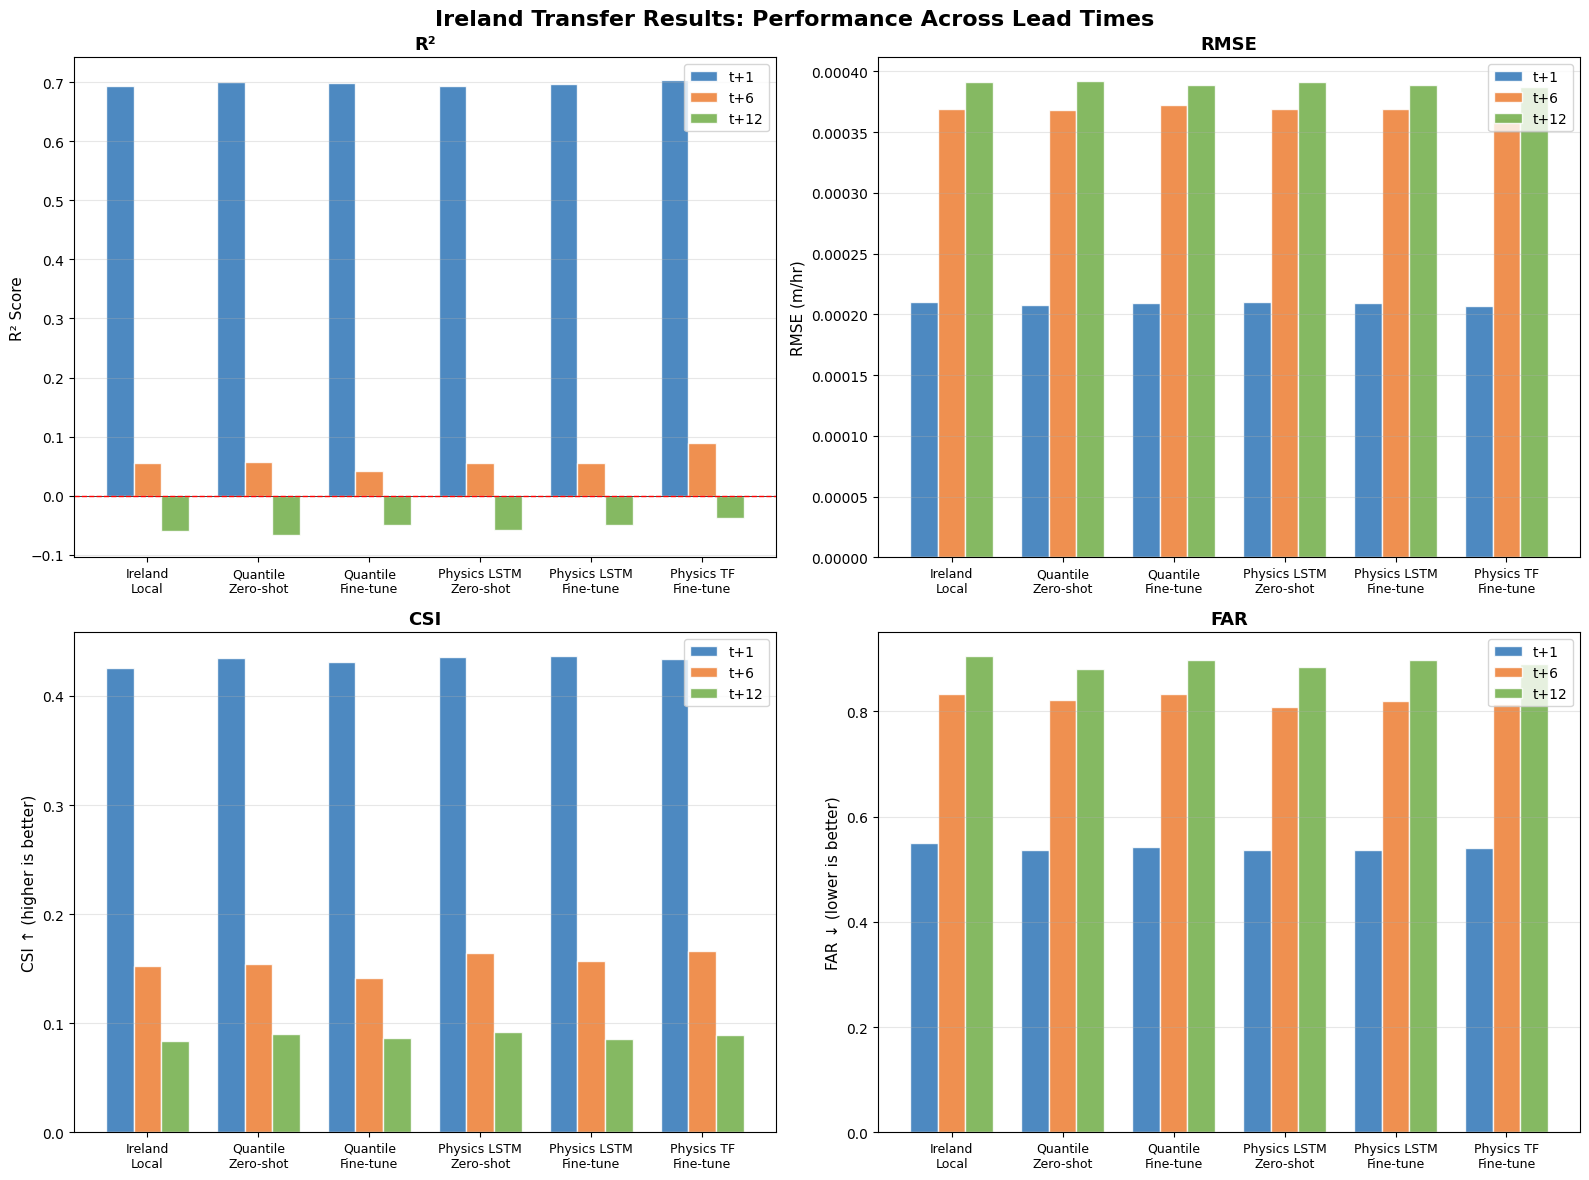

✅ 图1保存完成


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ── 数据 ──────────────────────────────────────────────────
models = ['Ireland\nLocal', 'Quantile\nZero-shot', 'Quantile\nFine-tune',
          'Physics LSTM\nZero-shot', 'Physics LSTM\nFine-tune', 'Physics TF\nFine-tune']

# R²
r2 = {
    't+1':  [0.6928,  0.6994,  0.6980,  0.6938,  0.6966,  0.7033],
    't+6':  [0.0549,  0.0577,  0.0413,  0.0558,  0.0554,  0.0890],
    't+12': [-0.0594, -0.0657, -0.0495, -0.0584, -0.0496, -0.0378],
}
# RMSE
rmse = {
    't+1':  [0.000210, 0.000208, 0.000209, 0.000210, 0.000209, 0.000207],
    't+6':  [0.000369, 0.000368, 0.000372, 0.000369, 0.000369, 0.000362],
    't+12': [0.000391, 0.000392, 0.000389, 0.000391, 0.000389, 0.000387],
}
# CSI
csi = {
    't+1':  [0.4254, 0.4349, 0.4310, 0.4356, 0.4365, 0.4341],
    't+6':  [0.1520, 0.1539, 0.1417, 0.1646, 0.1570, 0.1659],
    't+12': [0.0835, 0.0903, 0.0863, 0.0921, 0.0859, 0.0896],
}
# FAR
far = {
    't+1':  [0.5494, 0.5373, 0.5430, 0.5367, 0.5355, 0.5404],
    't+6':  [0.8322, 0.8205, 0.8326, 0.8081, 0.8204, 0.8129],
    't+12': [0.9047, 0.8807, 0.8967, 0.8847, 0.8972, 0.8898],
}

colors = {'t+1': '#2E75B6', 't+6': '#ED7D31', 't+12': '#70AD47'}
x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ireland Transfer Results: Performance Across Lead Times', fontsize=16, fontweight='bold')

datasets = [
    (axes[0,0], r2,   'R²',   'R² Score',        False),
    (axes[0,1], rmse, 'RMSE', 'RMSE (m/hr)',      False),
    (axes[1,0], csi,  'CSI',  'CSI ↑ (higher is better)', False),
    (axes[1,1], far,  'FAR',  'FAR ↓ (lower is better)',  False),
]

for ax, data, title, ylabel, _ in datasets:
    for i, (lead, vals) in enumerate(data.items()):
        bars = ax.bar(x + (i - 1) * width, vals, width,
                      label=lead, color=colors[lead], alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

# 在 R² 图加理想线
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=1, label='R²=0 baseline')

plt.tight_layout()
plt.savefig('/root/autodl-tmp/fig1_leadtime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图1保存完成")